In [1]:
import sys
import os

os.chdir("C:/Users/marco/job-search-engine")
sys.path.insert(0, "C:/Users/marco/job-search-engine")

import pandas as pd
from app.retriever import Retriever

# Load data and build both indexes
df = pd.read_parquet("data/cleaned_jobs.parquet")
r = Retriever(df)

# Test queries
queries = [
    "machine learning engineer remote",
    "data analyst entry level",
    "python developer fintech",
    "data scientist healthcare",
    "business intelligence analyst"
]

# Compare results side by side
for query in queries:
    faiss_results = r.search(query, top_k=3)
    bm25_results = r.search_bm25(query, top_k=3)

    print(f"\nQuery: '{query}'")
    print(f"{'FAISS':^55} | {'BM25':^55}")
    print("-" * 113)
    for f, b in zip(faiss_results, bm25_results):
        f_str = f"{f['title'][:30]} ({f['score']})"
        b_str = f"{b['title'][:30]} ({b['score']})"
        print(f"{f_str:<55} | {b_str:<55}")

Encoding 43484 job postings...
Index built with 43484 vectors.
Building BM25 index...
BM25 ready.

Query: 'machine learning engineer remote'
                         FAISS                          |                          BM25                          
-----------------------------------------------------------------------------------------------------------------
Analytics Engineer (0.7963)                             | Machine Learning with Data Ana (16.6693)               
Machine Learning Engineer/Data (0.7519)                 | Analytics Engineer (16.5268)                           
Data Scientist- Machine Learni (0.7499)                 | Sr.Data Analyst/Data Engineer  (16.4573)               

Query: 'data analyst entry level'
                         FAISS                          |                          BM25                          
-----------------------------------------------------------------------------------------------------------------
Entry-Level Data Analyst (

In [2]:
print("""
ABLATION FINDINGS
=================
BM25 strengths:
- Exact keyword matches (e.g. 'python developer' → finds Python jobs)
- Specific job titles users know by name

FAISS strengths:  
- Semantic similarity (e.g. 'machine learning' → finds 'Data Scientist' roles)
- Handles synonyms and related concepts

Production recommendation: hybrid search (BM25 + FAISS re-ranking)
This is the architecture used by Indeed, LinkedIn, and Google Jobs.
""")


ABLATION FINDINGS
BM25 strengths:
- Exact keyword matches (e.g. 'python developer' → finds Python jobs)
- Specific job titles users know by name

FAISS strengths:  
- Semantic similarity (e.g. 'machine learning' → finds 'Data Scientist' roles)
- Handles synonyms and related concepts

Production recommendation: hybrid search (BM25 + FAISS re-ranking)
This is the architecture used by Indeed, LinkedIn, and Google Jobs.



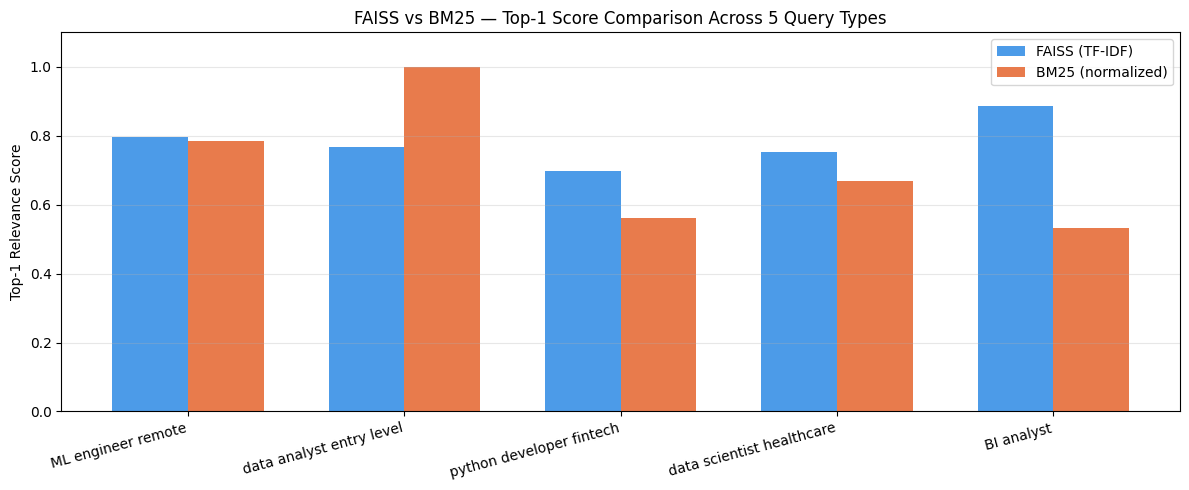

Chart saved to notebooks/faiss_vs_bm25.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

queries = [
    "ML engineer remote",
    "data analyst entry level", 
    "python developer fintech",
    "data scientist healthcare",
    "BI analyst"
]

# Top-1 scores from each method (from our earlier run)
faiss_scores = [0.7963, 0.7676, 0.6963, 0.7519, 0.8867]
bm25_scores  = [16.67, 21.28, 11.97, 14.23, 11.35]

# Normalize BM25 scores to 0-1 range for fair visual comparison
bm25_max = max(bm25_scores)
bm25_norm = [s / bm25_max for s in bm25_scores]

x = np.arange(len(queries))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, faiss_scores, width, label="FAISS (TF-IDF)", color="#4C9BE8")
bars2 = ax.bar(x + width/2, bm25_norm, width, label="BM25 (normalized)", color="#E87B4C")

ax.set_ylabel("Top-1 Relevance Score")
ax.set_title("FAISS vs BM25 — Top-1 Score Comparison Across 5 Query Types")
ax.set_xticks(x)
ax.set_xticklabels(queries, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("notebooks/faiss_vs_bm25.png", dpi=150)
plt.show()
print("Chart saved to notebooks/faiss_vs_bm25.png")